In [2]:
# ────────────────────────────────────────────────────────────────────────────────
# Cell 1: Imports and configuration
# ────────────────────────────────────────────────────────────────────────────────

import os
from pathlib import Path

import numpy as np
import nibabel as nib         # For loading NIfTI volumes
import cv2                    # For image normalization & drawing
from ultralytics import YOLO  # Ultralytics YOLO API

# ────────────────────────────────────────────────────────────────────────────────
# 1) Path to your trained YOLO model weights (adjust if yours differs)
WEIGHTS_PATH = "yolo_runs/yolo11_pubic_symphysis_s_aug/weights/best.pt"

# 2) Final confidence threshold for “positive” detection
#    (e.g. 0.10 or 0.05)
FINAL_CONF = 0.10

# 3) HU threshold below which we consider “background” (air/black)
#    Anything ≤ this is treated as outside patient.
BACKGROUND_HU = -300  

# 4) Toggle visualization of the first detected slice (True/False)
VISUALIZE = True

# Load the YOLO model once
model = YOLO(WEIGHTS_PATH)

In [3]:
# ────────────────────────────────────────────────────────────────────────────────
# Cell 2: Helper function to normalize a 2D CT slice → 3-channel BGR
# ────────────────────────────────────────────────────────────────────────────────

def preprocess_slice(ct_slice: np.ndarray) -> np.ndarray:
    """
    Given a single 2D CT slice (H×W, float or int HU), 
    normalize it to [0,255], convert to uint8, then to 3-channel BGR.
    Returns a (H, W, 3) uint8 array.
    """
    # 1. Min-max normalize to [0,1]
    arr = ct_slice.astype(np.float32)
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    # 2. Scale to [0,255] and convert to uint8
    arr = (arr * 255.0).astype(np.uint8)
    # 3. Convert single-channel → BGR (3 channels)
    bgr = cv2.cvtColor(arr, cv2.COLOR_GRAY2BGR)
    return bgr

In [7]:
# ────────────────────────────────────────────────────────────────────────────────
# Cell 3 (Revised for uniform green boxes): 
#   find_first_symphysis with Pelvic‐Zone + Stricter‐HU filtering
# ────────────────────────────────────────────────────────────────────────────────

def find_first_symphysis(ct_nifti_path: str):
    """
    Given a CT volume NIfTI, scan only the lower‐pelvis region first (based on slice index),
    applying both a confidence threshold (FINAL_CONF) and a stricter HU check (STRICT_HU).
    If no valid detection in that zone, fallback to scanning entire volume with a looser HU.
    Returns (slice_idx, (x1, y1, x2, y2), z_mm) or (None, None, None) if nothing valid.
    """
    # 1) Load the CT volume and extract raw data + affine
    ct_obj = nib.load(ct_nifti_path)
    ct_data = ct_obj.get_fdata()     # shape: (H, W, Z)
    affine = ct_obj.affine           # 4×4 affine matrix
    
    H, W, Z = ct_data.shape
    print(f"Loaded CT: {Path(ct_nifti_path).name} → shape {H}×{W}×{Z}")
    
    # 2) Define our “pelvic band” slice indices
    #    We'll only consider these indices first:
    LOC_LOW, LOC_HIGH = 0.30, 1.00  
    start_idx = int(Z * LOC_LOW)
    end_idx   = int(Z * LOC_HIGH) - 1
    
    # 3) Stricter HU cutoff for the pelvis band
    STRICT_HU = 0     # only accept centers with HU > 0 (true bone), avoids soft‐tissue fakes
    
    # 4) First pass: only scan slices in [start_idx … end_idx]
    for z in range(start_idx, end_idx + 1):
        slice_hu = ct_data[:, :, z]
        img_bgr = preprocess_slice(slice_hu)
        
        # Run YOLO at FINAL_CONF
        results = model.predict(
            source=img_bgr,
            conf=FINAL_CONF,
            device=0,
            save=False
        )[0]
        
        if len(results.boxes) == 0:
            continue
        
        # Sort boxes by confidence descending
        boxes = results.boxes
        sorted_ids = sorted(range(len(boxes)),
                            key=lambda i: float(boxes[i].conf),
                            reverse=True)
        
        # Check each box for HU > STRICT_HU
        for i in sorted_ids:
            b = boxes[i]
            conf_val = float(b.conf)
            x1, y1, x2, y2 = b.xyxy[0].tolist()
            
            # Box center
            x_center = int((x1 + x2) / 2.0)
            y_center = int((y1 + y2) / 2.0)
            
            # HU at center
            hu_center = float(slice_hu[y_center, x_center])
            if hu_center <= STRICT_HU:
                # center is not bone → skip
                continue
            
            # Found a valid detection in pelvis band:
            z_mm = affine[2, 2]*z + affine[2, 3]
            print(
                f"Detected symphysis [pelvis band] on slice {z} "
                f"(conf={conf_val:.3f}, z≈{z_mm:.1f} mm, HU={hu_center:.1f})"
            )
            print(f"  Box = [x1={x1:.1f}, y1={y1:.1f}, x2={x2:.1f}, y2={y2:.1f}]")
            
            if VISUALIZE:
                vis = img_bgr.copy()
                cv2.rectangle(
                    vis,
                    (int(x1), int(y1)),
                    (int(x2), int(y2)),
                    (0, 255, 0),    # green box
                    thickness=2
                )
                import matplotlib.pyplot as plt
                plt.figure(figsize=(6,6))
                plt.title(
                    f"Slice {z} (pelvis band)  z≈{z_mm:.1f} mm, HU={hu_center:.1f}, conf={conf_val:.3f}"
                )
                plt.axis("off")
                plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
                plt.show()
            
            return z, (x1, y1, x2, y2), z_mm
    
    # 5) If we got here, no valid detection in lower pelvis slices.
    #    Now do a fallback: scan **all slices** but with a looser HU cutoff (BACKGROUND_HU)
    print("→ No pelvis‐band detection. Trying fallback over entire volume with BACKGROUND_HU.")
    for z in range(Z):
        slice_hu = ct_data[:, :, z]
        img_bgr = preprocess_slice(slice_hu)
        
        results = model.predict(
            source=img_bgr,
            conf=FINAL_CONF,
            device=0,
            save=False
        )[0]
        
        if len(results.boxes) == 0:
            continue
        
        boxes = results.boxes
        sorted_ids = sorted(range(len(boxes)),
                            key=lambda i: float(boxes[i].conf),
                            reverse=True)
        
        # Now use the original BACKGROUND_HU (e.g. -300) to filter
        for i in sorted_ids:
            b = boxes[i]
            conf_val = float(b.conf)
            x1, y1, x2, y2 = b.xyxy[0].tolist()
            x_center = int((x1 + x2) / 2.0)
            y_center = int((y1 + y2) / 2.0)
            hu_center = float(slice_hu[y_center, x_center])
            
            if hu_center <= BACKGROUND_HU:
                continue
            
            # Accept this fallback detection
            z_mm = affine[2, 2]*z + affine[2, 3]
            print(
                f"Detected symphysis [fallback] on slice {z} "
                f"(conf={conf_val:.3f}, z≈{z_mm:.1f} mm, HU={hu_center:.1f})"
            )
            print(f"  Box = [x1={x1:.1f}, y1={y1:.1f}, x2={x2:.1f}, y2={y2:.1f}]")
            
            if VISUALIZE:
                vis = img_bgr.copy()
                cv2.rectangle(
                    vis,
                    (int(x1), int(y1)),
                    (int(x2), int(y2)),
                    (0, 255, 0),    # also green now
                    thickness=2
                )
                import matplotlib.pyplot as plt
                plt.figure(figsize=(6,6))
                plt.title(
                    f"Slice {z} (fallback)  z≈{z_mm:.1f} mm, HU={hu_center:.1f}, conf={conf_val:.3f}"
                )
                plt.axis("off")
                plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
                plt.show()
            
            return z, (x1, y1, x2, y2), z_mm
    
    # 6) Nothing found at all
    print(f"No symphysis detected (pelvis‐band + fallback). Flagging for manual review.")
    return None, None, None

Loaded CT: ct.nii.gz → shape 512×512×103

0: 768x768 (no detections), 123.5ms
Speed: 3.3ms preprocess, 123.5ms inference, 0.7ms postprocess per image at shape (1, 3, 768, 768)

0: 768x768 (no detections), 47.1ms
Speed: 3.3ms preprocess, 47.1ms inference, 0.7ms postprocess per image at shape (1, 3, 768, 768)

0: 768x768 (no detections), 35.3ms
Speed: 6.5ms preprocess, 35.3ms inference, 0.6ms postprocess per image at shape (1, 3, 768, 768)

0: 768x768 (no detections), 18.8ms
Speed: 3.4ms preprocess, 18.8ms inference, 0.5ms postprocess per image at shape (1, 3, 768, 768)

0: 768x768 (no detections), 6.3ms
Speed: 2.4ms preprocess, 6.3ms inference, 0.4ms postprocess per image at shape (1, 3, 768, 768)

0: 768x768 (no detections), 6.9ms
Speed: 2.5ms preprocess, 6.9ms inference, 0.5ms postprocess per image at shape (1, 3, 768, 768)

0: 768x768 (no detections), 6.3ms
Speed: 2.2ms preprocess, 6.3ms inference, 0.7ms postprocess per image at shape (1, 3, 768, 768)

0: 768x768 (no detections), 6.2

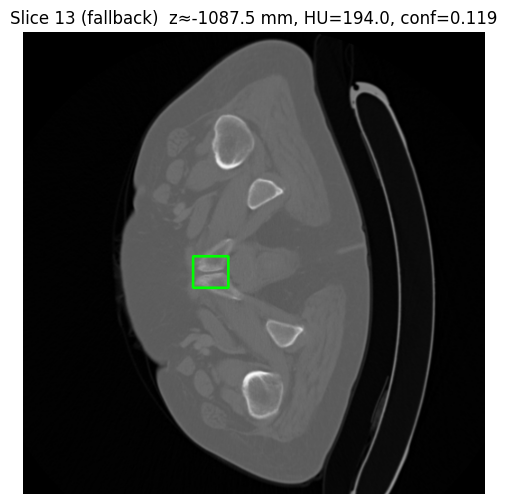


✅ Found pubic symphysis:
  • Slice index: 13
  • Bounding box (pixels): (188.206787109375, 248.52793884277344, 227.822265625, 283.16851806640625)
  • Z (world mm): -1087.5 mm


In [17]:
# ────────────────────────────────────────────────────────────────────────────────
# Cell 4: Example usage – set `new_ct_path` to the CT you want to test
# ────────────────────────────────────────────────────────────────────────────────

# 1) Replace this with your actual CT NIfTI path:
#    e.g. r"C:\Users\Ryan Krishna\Documents\Overscanning\Patient_CTs\Patient123\ct.nii.gz"
new_ct_path = r"C:\Users\Ryan Krishna\Documents\Overscanning\Patient_CTs\Patient004\ct.nii.gz"

# 2) Call the function
first_slice_index, bbox_pixels, z_coordinate_mm = find_first_symphysis(new_ct_path)

# 3) Print results
if first_slice_index is not None:
    print("\n✅ Found pubic symphysis:")
    print(f"  • Slice index: {first_slice_index}")
    print(f"  • Bounding box (pixels): {bbox_pixels}")
    print(f"  • Z (world mm): {z_coordinate_mm:.1f} mm")
else:
    print("\n⚠️  Pubic symphysis was NOT detected in this volume.")